# End-to-End Unsupervised Pipeline — Text Clustering on 20 Newsgroups

## What you'll learn

How to take **unlabeled text** and discover groups in it. We use a small subset of the 20 Newsgroups dataset because it has natural topic clusters (so we can sanity-check our clustering against the *real* topics it never saw).

## The Universal Unsupervised Pipeline

```
1. Define problem        → segmentation? topic discovery? anomaly detection?
2. Load data             → DataFrame of raw text
3. EDA                   → length distributions, sample documents
4. NLP preprocessing     → clean → tokenize → stopwords → lemmatize
5. Vectorize             → TF-IDF (or embeddings)
6. Reduce dimensions     → SVD/UMAP — distance is meaningless in 5,000-D
7. Choose K              → elbow + silhouette
8. Try multiple algos    → K-Means / Agglomerative / DBSCAN
9. Evaluate              → silhouette + (if labels exist) ARI/NMI
10. Inspect clusters     → top terms per cluster, sample docs per cluster
11. Visualize            → 2D scatter (after PCA / UMAP / t-SNE)
12. Save artifact        → preprocessor + vectorizer + reducer + model
13. Reload & assign      → embed a new doc, get its cluster id
```

**Why 20 Newsgroups (subset)?** It ships with sklearn (no download), has clear thematic groups (sports, religion, tech, autos), the right size for laptop-speed iteration, and it gives us **labels we can withhold** to measure clustering quality.

---

## Step 0: Imports

In [1]:
import os, re, json, pickle, joblib, sys
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
print('Imports OK')

Imports OK


## Step 1: Define the problem

1. **Goal:** group similar newsgroup posts together without using the labels.
2. **Use case (real-world parallel):** customer-support tickets, news articles by topic, product reviews by theme.
3. **What's a "good" cluster?** — high cohesion (members similar) and high separation (clusters distinct), with each cluster representing a coherent topic when you read sample documents.
4. **Validation:** because this dataset *has* hidden labels, we can also compare our clusters against true topics with **ARI** and **NMI**. In a real unsupervised problem you wouldn't have this luxury — you'd rely on silhouette + reading samples + downstream task quality.

## Step 2: Load the data

Pick 4 newsgroups so it's tractable on a laptop and the topics are clearly distinct. Strip headers/footers/quotes — they leak strong cues like email addresses and signatures.

In [2]:
categories = ['rec.sport.baseball', 'sci.space', 'comp.graphics', 'talk.politics.mideast']
data = fetch_20newsgroups(subset='all', categories=categories,
                          remove=('headers', 'footers', 'quotes'),
                          random_state=RANDOM_STATE)

df = pd.DataFrame({'text': data.data, 'true_label': data.target})
df['true_topic'] = df['true_label'].map({i: c for i, c in enumerate(data.target_names)})
# Drop tiny / empty docs
df = df[df['text'].str.len() > 50].reset_index(drop=True)
print(f'Documents: {len(df)}')
print(df['true_topic'].value_counts())

Documents: 3681
sci.space                942
comp.graphics            930
rec.sport.baseball       921
talk.politics.mideast    888
Name: true_topic, dtype: int64


## Step 3: EDA — what does the text look like?

       n_chars  n_words
count   3681.0   3681.0
mean    1410.2    226.9
std     4184.2    655.1
min       51.0      1.0
25%      262.0     45.0
50%      520.0     89.0
75%     1118.0    189.0
max    61686.0  11198.0


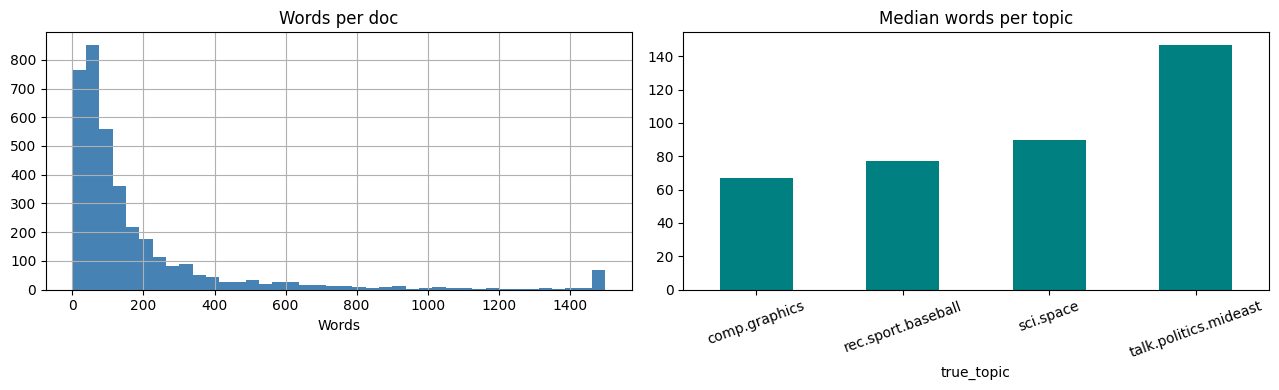


Sample document:

What is the copyright status of this data?  Are there restrictions regarding the
uses they can be put to?

Kaveh




In [3]:
df['n_chars'] = df['text'].str.len()
df['n_words'] = df['text'].str.split().str.len()
print(df[['n_chars', 'n_words']].describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df['n_words'].clip(upper=1500).hist(bins=40, ax=ax[0], color='steelblue')
ax[0].set_title('Words per doc'); ax[0].set_xlabel('Words')
df.groupby('true_topic')['n_words'].median().plot.bar(ax=ax[1], color='teal')
ax[1].set_title('Median words per topic'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

print('\nSample document:')
print(df['text'].iloc[0][:400])

## Step 4: NLP preprocessing

**For clustering text, the cleaning chain is similar to classification but slightly different:**
- Stem/lemmatize aggressively → fewer columns, denser TF-IDF.
- Drop very rare tokens (`min_df=5`) — they're noise that creates bogus tiny clusters.
- Drop very common tokens (`max_df=0.5`) — they appear everywhere and don't separate topics.

**Why these `min_df` / `max_df` choices matter so much in clustering:** with TF-IDF, distance is computed on every term. Noise terms make distances meaningless. Aggressive vocabulary pruning is unsupervised's biggest accuracy lever.

In [4]:
try:
    import nltk
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    from nltk.corpus import stopwords as nltk_stop
    from nltk.stem import WordNetLemmatizer
    STOPWORDS = set(nltk_stop.words('english'))
    lemmatizer = WordNetLemmatizer()
    HAS_NLTK = True
except Exception:
    HAS_NLTK = False
    STOPWORDS = set('a an the is are was were be been being of in on at to for with by and or but if it this that these those i you he she we they me him her us them my your his our their as'.split())
    lemmatizer = None

EMAIL_RE = re.compile(r'\S+@\S+')
URL_RE   = re.compile(r'https?://\S+|www\.\S+')
NUM_RE   = re.compile(r'\b\d+\b')
NONALPHA = re.compile(r"[^a-z\s]")
MULTISPACE = re.compile(r'\s+')

def clean_text(t: str) -> str:
    t = t.lower()
    t = EMAIL_RE.sub(' ', t)
    t = URL_RE.sub(' ', t)
    t = NUM_RE.sub(' ', t)
    t = NONALPHA.sub(' ', t)
    t = MULTISPACE.sub(' ', t).strip()
    tokens = [w for w in t.split() if w not in STOPWORDS and len(w) > 2]
    if lemmatizer is not None:
        tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

class TextCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return [clean_text(t) for t in X]

print('Preview:')
print('ORIG :', df['text'].iloc[0][:160])
print('CLEAN:', clean_text(df['text'].iloc[0])[:160])

Preview:
ORIG : 
What is the copyright status of this data?  Are there restrictions regarding the
uses they can be put to?

Kaveh




[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1007)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1007)>


CLEAN: copyright status data restriction regarding us put kaveh


## Step 5: Vectorize with TF-IDF

**Why TF-IDF for clustering?**
- Each doc → a sparse vector across the vocabulary.
- Common-everywhere words get downweighted automatically.
- Cosine distance on TF-IDF works extremely well as a topic similarity signal.

**Why `sublinear_tf=True`?** Reduces the impact of very high term counts — important when one document repeats a word many times.

In [5]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.5,
    sublinear_tf=True,
)

cleaned = TextCleaner().fit_transform(df['text'].tolist())
X_tfidf = vectorizer.fit_transform(cleaned)
print(f'TF-IDF shape: {X_tfidf.shape}  (docs × terms)')

TF-IDF shape: (3681, 14030)  (docs × terms)


## Step 6: Reduce dimensions with TruncatedSVD (LSA)

**Why?** Clustering high-dimensional sparse vectors is unreliable — distance loses meaning (curse of dimensionality). **LSA** (Latent Semantic Analysis) is just SVD on TF-IDF — it projects to a dense low-dim space where semantically similar docs end up close.

**Then L2-normalize** so cosine similarity = Euclidean distance / 2 — lets us use plain K-Means.

In [6]:
svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)
X_svd = normalize(X_svd)
print(f'After SVD : {X_svd.shape}')
print(f'Variance explained by 100 components: {svd.explained_variance_ratio_.sum():.3f}')

After SVD : (3681, 100)
Variance explained by 100 components: 0.159


## Step 7: Choose K with Elbow + Silhouette

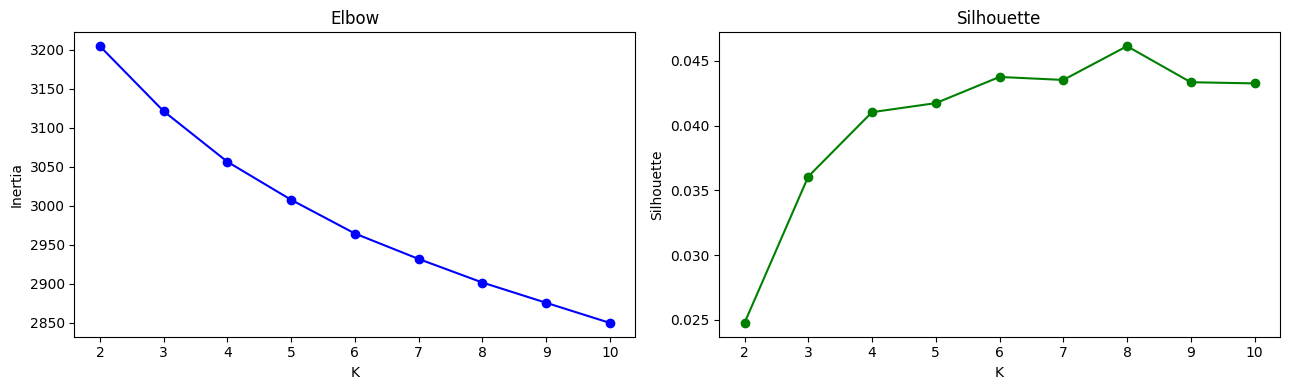

We know there are 4 true topics — K=4 should be the answer.
In a real unsupervised problem, pick K where elbow bends + silhouette peaks (often disagree slightly — combine with domain knowledge).


In [7]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_svd)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_svd, km.labels_, sample_size=2000, random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(ks, inertias, 'b-o'); ax[0].set_xlabel('K'); ax[0].set_ylabel('Inertia'); ax[0].set_title('Elbow')
ax[1].plot(ks, sils, 'g-o'); ax[1].set_xlabel('K'); ax[1].set_ylabel('Silhouette'); ax[1].set_title('Silhouette')
plt.tight_layout(); plt.show()

print('We know there are 4 true topics — K=4 should be the answer.')
print('In a real unsupervised problem, pick K where elbow bends + silhouette peaks (often disagree slightly — combine with domain knowledge).')
K = 4

## Step 8: Try multiple clustering algorithms

In [8]:
rows = []
results = {}

for name, model in [
    ('K-Means (K=4)', KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)),
    ('Agglomerative (ward, K=4)', AgglomerativeClustering(n_clusters=K, linkage='ward')),
    ('DBSCAN (eps=0.5)', DBSCAN(eps=0.5, min_samples=10, metric='cosine')),
]:
    labels = model.fit_predict(X_svd)
    valid = labels != -1
    sil = silhouette_score(X_svd[valid], labels[valid]) if valid.sum() > K else np.nan
    ari = adjusted_rand_score(df['true_label'], labels)
    nmi = normalized_mutual_info_score(df['true_label'], labels)
    n_noise = int((labels == -1).sum())
    n_clusters = int(len(set(labels)) - (1 if -1 in labels else 0))
    rows.append({
        'model': name, 'n_clusters': n_clusters, 'noise': n_noise,
        'silhouette': round(sil, 3), 'ARI': round(ari, 3), 'NMI': round(nmi, 3)
    })
    results[name] = labels

print(pd.DataFrame(rows).to_string(index=False))

                    model  n_clusters  noise  silhouette   ARI   NMI
            K-Means (K=4)           4      0       0.041 0.681 0.659
Agglomerative (ward, K=4)           4      0       0.035 0.474 0.506
         DBSCAN (eps=0.5)           2    212       0.021 0.000 0.007


## Step 9: Inspect clusters — top terms + sample documents

**This is the unsupervised equivalent of "reading misclassified examples".** A cluster is good if its top terms tell a coherent story and its sample docs are clearly on-topic.

In [9]:
labels = results['K-Means (K=4)']
df['cluster'] = labels

# Top terms per cluster — find centroids in original TF-IDF space
km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X_svd)
# Project centroids back to TF-IDF terms via SVD components
original_centroids = svd.inverse_transform(km.cluster_centers_)
vocab = np.array(vectorizer.get_feature_names_out())

print('Top 12 terms per cluster:\n')
for c in range(K):
    top_idx = np.argsort(original_centroids[c])[::-1][:12]
    print(f"Cluster {c}:  {', '.join(vocab[top_idx])}")

print('\nCross-tab vs true topics:')
print(pd.crosstab(df['true_topic'], df['cluster']))

Top 12 terms per cluster:

Cluster 0:  israel, arab, jew, israeli, people, one, muslim, jewish, armenian, would, state, right
Cluster 1:  space, would, one, orbit, like, think, launch, thing, earth, nasa, time, could
Cluster 2:  thanks, file, graphic, anyone, please, image, know, program, would, like, format, help
Cluster 3:  game, year, team, think, player, baseball, hit, last, run, pitcher, one, season

Cross-tab vs true topics:
cluster                  0    1    2    3
true_topic                               
comp.graphics            0   36  878   16
rec.sport.baseball       7    8   85  821
sci.space               14  753  152   23
talk.politics.mideast  754   28   73   33


In [10]:
# Sample 2 documents from each cluster
for c in range(K):
    print(f'\n=== Cluster {c} samples ===')
    for txt in df[df.cluster == c]['text'].sample(2, random_state=RANDOM_STATE):
        print('•', txt.strip().replace('\n',' ')[:160], '...')


=== Cluster 0 samples ===
• "Muslim" in ex-Yugoslavia was a *nation* not a religion.  In fact, not all Muslims in B-H are followers of Islam.  Therefore, there do (did?) exist in ex-Yugosl ...
• I don't like this comment about "Typical" thinking. You could state your interpretation of Exodus without it. As I read Exodus I can see  a lot of killing there ...

=== Cluster 1 samples ===
• There was a Science fiction movie sometime ago (I do not remember its  name) about a planet in the same orbit of Earth but hidden behind the  Sun so it could ne ...
• Yes, and I do everyone else.  Why, you may wonder, don't I do 'Fred'? Well, that would just be too *obvious*, wouldn't it?  Oh yeah, this isn't my real name, ei ...

=== Cluster 2 samples ===
• Hi, can anyone direct me to map type gifs?   I am interesting in cartography and would find these gifs useful.  tia, ...
• Sorry about not mentioning platform... my original post was to mac.programmer, and then decided to post here to comp.graphics.

## Step 10: Visualize in 2D

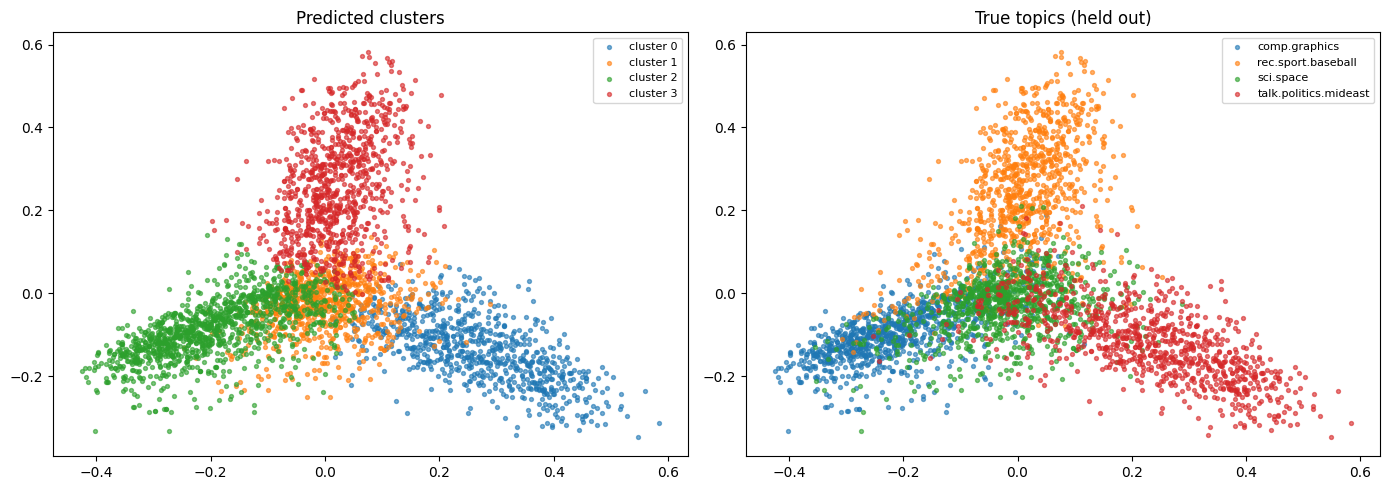

Compare side-by-side: same regions of space → clusters approximate the true topics.


In [11]:
X_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_svd)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for c in range(K):
    m = df['cluster'] == c
    ax[0].scatter(X_2d[m, 0], X_2d[m, 1], s=8, alpha=0.6, label=f'cluster {c}')
ax[0].set_title('Predicted clusters'); ax[0].legend(fontsize=8)

for i, t in enumerate(data.target_names):
    m = df['true_label'] == i
    ax[1].scatter(X_2d[m, 0], X_2d[m, 1], s=8, alpha=0.6, label=t)
ax[1].set_title('True topics (held out)'); ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()
print('Compare side-by-side: same regions of space → clusters approximate the true topics.')

## Step 11: Build the full Pipeline (cleaner → vectorizer → SVD → normalize → K-Means)

We do this AFTER picking K so that we save a single artifact that takes raw text and returns a cluster id.

In [12]:
from sklearn.preprocessing import Normalizer

full_pipeline = Pipeline([
    ('clean',     TextCleaner()),
    ('tfidf',     TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.5, sublinear_tf=True)),
    ('svd',       TruncatedSVD(n_components=100, random_state=RANDOM_STATE)),
    ('normalize', Normalizer()),
    ('kmeans',    KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)),
])

labels_pipe = full_pipeline.fit_predict(df['text'].tolist())
ari = adjusted_rand_score(df['true_label'], labels_pipe)
print(f'Full-pipeline ARI vs true topics: {ari:.3f}')

Full-pipeline ARI vs true topics: 0.681


## Step 12: Save the artifact

**Why save the whole pipeline?** Inference on a new document needs the *same* preprocessing → vectorizer vocab → SVD components → centroids. Saving them separately is a recipe for bugs.

In [13]:
import sklearn
ART_DIR = 'artifacts_unsupervised'
os.makedirs(ART_DIR, exist_ok=True)

with open(f'{ART_DIR}/cluster_model.pkl', 'wb') as f:
    pickle.dump(full_pipeline, f)
joblib.dump(full_pipeline, f'{ART_DIR}/cluster_model.joblib', compress=3)

# Save a human-readable cluster summary
cluster_summary = {}
for c in range(K):
    top_idx = np.argsort(original_centroids[c])[::-1][:12]
    cluster_summary[f'cluster_{c}'] = {
        'top_terms' : vocab[top_idx].tolist(),
        'size'      : int((labels == c).sum()),
    }

metadata = {
    'model_name'   : 'newsgroups-text-clustering',
    'version'      : '1.0.0',
    'trained_at'   : datetime.utcnow().isoformat() + 'Z',
    'n_clusters'   : K,
    'n_documents'  : len(df),
    'metrics'      : {
        'silhouette' : float(silhouette_score(X_svd, labels)),
        'ARI_vs_known_labels': float(ari),
        'NMI_vs_known_labels': float(normalized_mutual_info_score(df['true_label'], labels)),
    },
    'cluster_summary': cluster_summary,
    'env': {
        'python'  : sys.version.split()[0],
        'sklearn' : sklearn.__version__,
        'numpy'   : np.__version__,
        'pandas'  : pd.__version__,
    },
}
with open(f'{ART_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved pickle ({os.path.getsize(f'{ART_DIR}/cluster_model.pkl'):,} bytes), " \
      f"joblib ({os.path.getsize(f'{ART_DIR}/cluster_model.joblib'):,} bytes)")
print('Cluster summaries:')
print(json.dumps(cluster_summary, indent=2))

Saved pickle (16,570,053 bytes), joblib (12,324,397 bytes)
Cluster summaries:
{
  "cluster_0": {
    "top_terms": [
      "israel",
      "arab",
      "jew",
      "israeli",
      "people",
      "one",
      "muslim",
      "jewish",
      "armenian",
      "would",
      "state",
      "right"
    ],
    "size": 775
  },
  "cluster_1": {
    "top_terms": [
      "space",
      "would",
      "one",
      "orbit",
      "like",
      "think",
      "launch",
      "thing",
      "earth",
      "nasa",
      "time",
      "could"
    ],
    "size": 825
  },
  "cluster_2": {
    "top_terms": [
      "thanks",
      "file",
      "graphic",
      "anyone",
      "please",
      "image",
      "know",
      "program",
      "would",
      "like",
      "format",
      "help"
    ],
    "size": 1188
  },
  "cluster_3": {
    "top_terms": [
      "game",
      "year",
      "team",
      "think",
      "player",
      "baseball",
      "hit",
      "last",
      "run",
      "pitcher",
  

## Step 13: Reload + assign new documents

End-to-end smoke test with brand-new sentences.

In [14]:
loaded = joblib.load(f'{ART_DIR}/cluster_model.joblib')
summary = json.load(open(f'{ART_DIR}/metadata.json'))['cluster_summary']

new_docs = [
    'NASA announced a new mission to explore Europa, Jupiter\'s icy moon.',
    'The Yankees won last night with a walk-off home run in the ninth.',
    'I\'m using OpenGL to render a 3D mesh and the texture mapping looks off.',
    'Negotiations between the two governments continue with no clear resolution.',
]

predicted = loaded.predict(new_docs)
for doc, c in zip(new_docs, predicted):
    print(f'\n[Cluster {c}]', doc)
    print(f'   Top terms in cluster: {", ".join(summary[f"cluster_{c}"]["top_terms"][:6])}')


[Cluster 1] NASA announced a new mission to explore Europa, Jupiter's icy moon.
   Top terms in cluster: space, would, one, orbit, like, think

[Cluster 3] The Yankees won last night with a walk-off home run in the ninth.
   Top terms in cluster: game, year, team, think, player, baseball

[Cluster 2] I'm using OpenGL to render a 3D mesh and the texture mapping looks off.
   Top terms in cluster: thanks, file, graphic, anyone, please, image

[Cluster 0] Negotiations between the two governments continue with no clear resolution.
   Top terms in cluster: israel, arab, jew, israeli, people, one


---
## Pipeline Recap — the unsupervised text-clustering template

| # | Step | Notes |
|---|------|-------|
| 1 | Define problem | What is a "good" cluster? |
| 2 | Load data | DataFrame of raw text |
| 3 | EDA | Lengths, samples, vocabulary scale |
| 4 | Clean text | Lowercase, strip URLs/numbers, lemmatize |
| 5 | TF-IDF | `sublinear_tf=True`, prune `min_df`/`max_df` aggressively |
| 6 | Reduce dim | TruncatedSVD (100D), then L2-normalize |
| 7 | Pick K | Elbow + silhouette + domain knowledge |
| 8 | Try algos | K-Means / Agglomerative / DBSCAN |
| 9 | Inspect | Top terms + sample docs per cluster |
| 10 | Visualize | 2D scatter via PCA / UMAP / t-SNE |
| 11 | Wrap pipeline | Cleaner → TFIDF → SVD → Normalize → KMeans |
| 12 | Save | joblib + pickle + metadata + cluster summary |
| 13 | Reload | Predict cluster id for new docs |

## Things to swap when you have a different dataset

| If your data... | Change |
|-----------------|--------|
| Numeric tabular | Skip text steps; StandardScale → PCA → K-Means |
| Customer transactions | RFM features (Recency, Frequency, Monetary) → cluster |
| Images | Use embeddings from a pretrained CNN, then cluster |
| Very large corpus | Use `MiniBatchKMeans` (streams, memory-friendly) |
| Outlier detection | Use DBSCAN/HDBSCAN — `-1` label is your anomaly score |
| Hierarchical needs | Agglomerative + dendrogram; pick cut height visually |
| Need topics, not just clusters | LDA / NMF / BERTopic — designed for topic modeling |
| High-quality semantics | Replace TF-IDF with sentence-transformers embeddings (`all-MiniLM-L6-v2`) |